# Brain Tumor Detection (VGG16 Binary Classification)

Versión adaptada al dataset de Kaggle:

- yes = tumor presente
- no = tumor ausente

Incluye:
- Train / Validation / Test
- VGG16 Transfer Learning
- Accuracy, Precision, Recall y F1
- Matriz de confusión
- Curvas de entrenamiento
- model.save()
- load_model()

In [5]:
# pip install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## Hyperparameters

In [9]:

IMG_SIZE = (256,256)
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 0.001
DROPOUT = 0.4

TRAIN_DIR = "dataset__readytouse/train"
VAL_DIR = "dataset__readytouse/validation"
TEST_DIR = "dataset__readytouse/test"


## Dataset Structure
```text
dataset/
├── train/
│   ├── yes/
│   └── no/
├── validation/
│   ├── yes/
│   └── no/
└── test/
    ├── yes/
    └── no/
```

En TensorFlow/Keras, la asignación de etiquetas para conjuntos de datos estructurados en carpetas locales no requiere un etiquetado manual en código. Funciones como `image_dataset_from_directory()` automatizan este proceso mediante **inferencia topológica**.

```text
dataset/
├── train/
│   ├── yes/  --> Clase 1 (Alfabéticamente)
│   └── no/   --> Clase 0 

```

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset__readytouse/train",
    image_size=(256,256),
    batch_size=8,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset__readytouse/validation",
    image_size=(256,256),
    batch_size=8,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset__readytouse/test",
    image_size=(256,256),
    batch_size=8,
    label_mode="binary",
    shuffle=False # Solo en test queremos evitar el shuffle, para debuggear mejor.
)

print(train_ds.class_names)

Found 153 files belonging to 2 classes.
Found 50 files belonging to 2 classes.
Found 50 files belonging to 2 classes.
['no', 'yes']


## Build VGG16

In [14]:

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(256,256,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(DROPOUT)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile

In [15]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)


## Train

In [18]:

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        save_best_only=True,
        monitor="val_accuracy"
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds, 
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.6340 - loss: 2.4306 - precision_1: 0.6989 - recall_1: 0.6989 - val_accuracy: 0.7800 - val_loss: 0.6262 - val_precision_1: 0.7778 - val_recall_1: 0.9032
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.7320 - loss: 0.9553 - precision_1: 0.7600 - recall_1: 0.8172 - val_accuracy: 0.7800 - val_loss: 0.6459 - val_precision_1: 0.9545 - val_recall_1: 0.6774
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.7516 - loss: 0.8549 - precision_1: 0.7835 - recall_1: 0.8172 - val_accuracy: 0.7400 - val_loss: 0.7999 - val_precision_1: 1.0000 - val_recall_1: 0.5806
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.7778 - loss: 0.6297 - precision_1: 0.8105 - recall_1: 0.8280 - val_accuracy: 0.8000 - val_loss: 0.4718 - val_precision_1: 1.0000 - val_recall_1: 0.6774
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.8235 - loss: 0.4631 - precision_1: 0.8667 - recall_1: 0.8387 - val_

## Training Curves

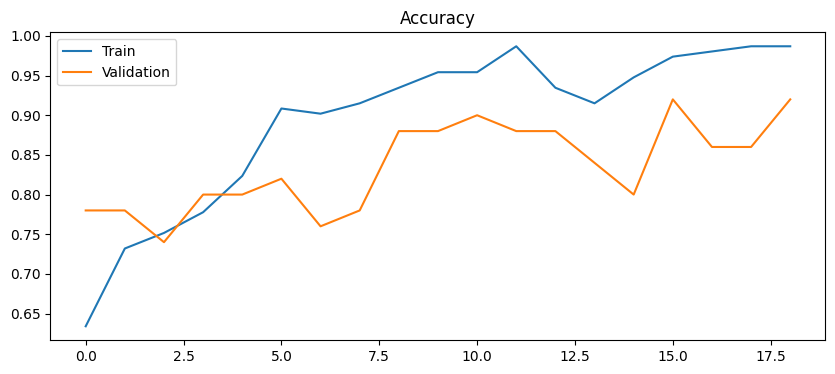

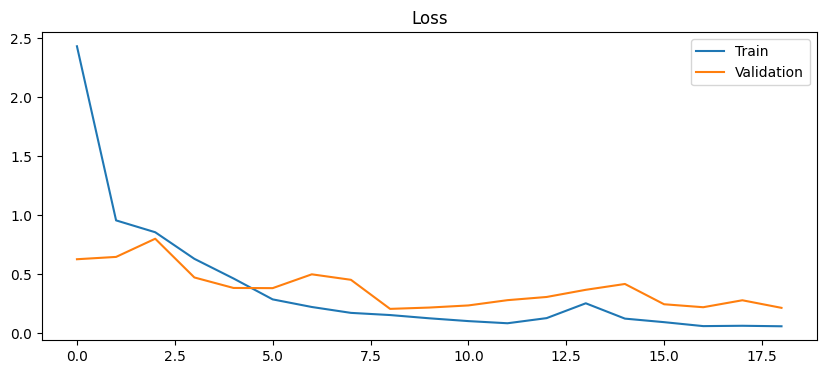

In [19]:

plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.show()


## Test Metrics

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predicciones del modelo
probs = model.predict(test_ds)

# Convertir probabilidades a clases binarias
y_pred = (probs > 0.5).astype(int).flatten()

# Etiquetas reales
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
]).astype(int)

# Métricas
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["no", "yes"]
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Accuracy : 0.92
Precision: 0.9090909090909091
Recall   : 0.967741935483871
F1 Score : 0.9375

Classification Report
              precision    recall  f1-score   support

          no       0.94      0.84      0.89        19
         yes       0.91      0.97      0.94        31

    accuracy                           0.92        50
   macro avg       0.93      0.90      0.91        50
weighted avg       0.92      0.92      0.92        50



## Confusion Matrix

[[16  3]
 [ 1 30]]


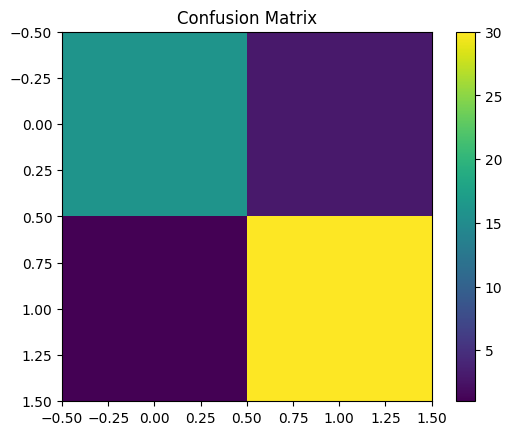

In [24]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

## Save Model

In [2]:

model.save("finalModel.keras")
print("Model saved.")


NameError: name 'model' is not defined

## Load Saved Model

In [1]:

loaded_model = load_model(
    "finalModel.keras"
)

loaded_model.summary()


NameError: name 'load_model' is not defined

## Single Image Inference

In [27]:

from tensorflow.keras.preprocessing import image

img_path = "singles/example_no.png"

img = image.load_img(
    img_path,
    target_size=(256,256)
)

x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

prob = model.predict(x)[0][0]

print("Tumor probability:", prob)

if prob > 0.5:
    print("Prediction: YES (Tumor)")
else:
    print("Prediction: NO (Healthy)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Tumor probability: 0.48305938
Prediction: NO (Healthy)
